# Fast-PM mini-simulator + resimulation feasibility

The digital-twin core: a cheap full-volume sim carries the large scales; selected sub-volumes are **re-simulated** at higher fidelity. The fast-PM (CIC + FFT-Poisson + KDK leapfrog) is the mini-sim. We verify the physics **and** show where it stops working.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from oneuniverse.simulation.cosmology import CosmologySpec
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.simulation.linear.growth import growth_factor
from oneuniverse.simulation.pm.run import run_pm, zeldovich_pm_ic_from_field
from oneuniverse.simulation.pm.deposit import deposit_cic
from oneuniverse.simulation.resim.coupling import (run_full_reference,
    run_coupled, run_zoom, full_target_slice)
from oneuniverse.simulation.resim.cola import cola_run_pm
from oneuniverse.twin.verify import cross_correlation, power_ratio
C = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
BOX, N = 200.0, 64
def pk_delta(x, n, box):
    rho = deposit_cic(x, n, box); return rho/rho.mean()-1

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The PM reproduces linear growth (sub-percent)
Evolve a linear field from z=9 to z=3 (still linear) and compare the low-k growth to the analytic factor D(z3)/D(z9).

In [2]:
d0 = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
pos, p0 = zeldovich_pm_ic_from_field(C, d0, box=BOX, n_grid=N, z_start=9.0)
def measure_lowk_ratio(a_end):
    x,_ = run_pm(pos, p0, box=BOX, n_grid=N, cosmo=C, a_start=0.1, a_end=a_end, n_steps=20)
    d = pk_delta(x, N, BOX)
    rho0 = deposit_cic(pos, N, BOX); dic = rho0/rho0.mean()-1
    k,_ = cross_correlation(d, dic, box_size=BOX); _,pr = power_ratio(d, dic, box_size=BOX)
    return float(np.sqrt(np.nanmedian(pr[k<0.06])))
meas = measure_lowk_ratio(0.25); exp = growth_factor(3.0,C)/growth_factor(9.0,C)
print(f'z9->z3 growth ratio   measured {meas:.3f}   analytic {exp:.3f}   err {100*(meas/exp-1):+.1f}%')

z9->z3 growth ratio   measured 2.479   analytic 2.486   err -0.3%


## 2. Resimulation feasibility — buffer convergence (the headline result)
Resimulate a target sub-cube on buffer-padded particles; compare the inner region to the full-box reference as the buffer grows.

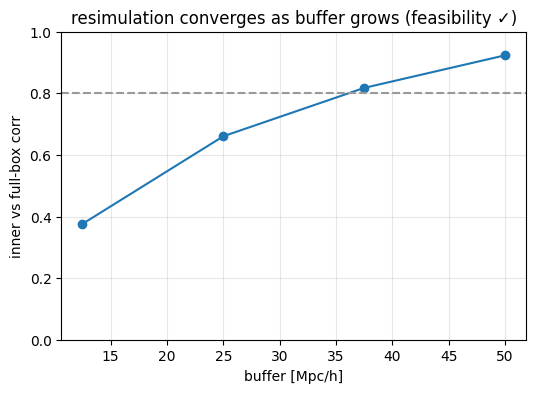

corr: [0.376 0.661 0.818 0.923]


In [3]:
full = run_full_reference(C, box=BOX, n_grid=N, z_start=9.0, z_end=0.0, seed=2, n_steps=18)
TLO, TS = 75.0, 50.0
ref = full_target_slice(full, box=BOX, n_grid=N, target_lo=TLO, target_side=TS)
buffers = [12.5, 25.0, 37.5, 50.0]
corr = []
for b in buffers:
    inner = run_coupled(C, box=BOX, n_grid=N, target_lo=TLO, target_side=TS,
                        buffer=b, z_start=9.0, z_end=0.0, seed=2, n_steps=18)['inner']
    corr.append(np.corrcoef(inner.ravel(), ref.ravel())[0,1])
plt.figure(figsize=(6,4)); plt.plot(buffers, corr, 'o-')
plt.axhline(0.8, color='.6', ls='--'); plt.ylim(0,1)
plt.xlabel('buffer [Mpc/h]'); plt.ylabel('inner vs full-box corr')
plt.title('resimulation converges as buffer grows (feasibility ✓)'); plt.grid(alpha=.3); plt.show()
print('corr:', np.round(corr,3))

## 3. True zoom — higher resolution adds small-scale power

In [4]:
box_buf, nc = 100.0, 24
coarse = generate_density_field(C, box_size=box_buf, n_grid=nc, z=0.0, seed=2)
res = run_zoom(C, coarse, box_buf=box_buf, target_side=50.0, buffer=25.0,
               factor=2, z_start=9.0, z_end=0.0, seed=9, n_steps=12)
print(f'parent grid {nc}  ->  zoom grid {res["n_fine"]}  (resolves beyond parent Nyquist)')

parent grid 24  ->  zoom grid 48  (resolves beyond parent Nyquist)


## 4. COLA frame — few steps reproduce the full PM on large scales

In [5]:
xf,_ = run_pm(pos, p0, box=BOX, n_grid=N, cosmo=C, a_start=0.1, a_end=1.0, n_steps=25)
df = pk_delta(xf, N, BOX)
xc = cola_run_pm(C, d0, box=BOX, n_grid=N, a_start=0.1, a_end=1.0, n_steps=5)
dc = pk_delta(xc, N, BOX)
k,r = cross_correlation(dc, df, box_size=BOX); _,pr = power_ratio(dc, df, box_size=BOX)
print(f'COLA 5 steps vs full-PM 25 steps:  r_lowk {np.nanmedian(r[k<0.1]):.3f}   '
      f'P/Pfull_lowk {np.nanmedian(pr[k<0.1]):.3f}')

COLA 5 steps vs full-PM 25 steps:  r_lowk 0.985   P/Pfull_lowk 1.023


## ⚠️ What is NOT working (the important ones)

### (a) sCOLA buffer coupling — DOES NOT beat the uncoupled run
The goal was: use the far-field/COLA frame so a *small* buffer suffices. Every coupling attempt is **worse** than the plain uncoupled resim (and inconsistent across buffer sizes). Correct sub-box sCOLA needs exact LPT boundary conditions (Tassev & Eisenstein 2015) — deferred. The plot below shows the failure directly.

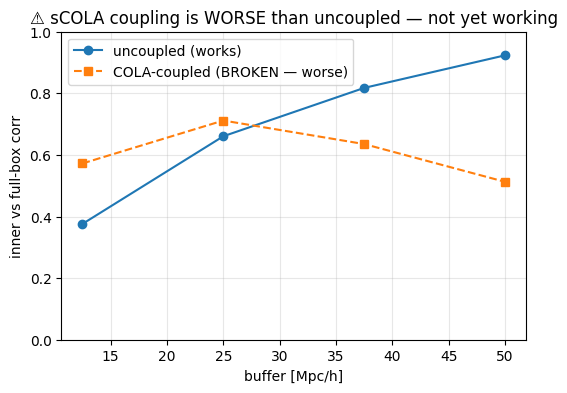

In [6]:
from oneuniverse.simulation.pm.run import _zeldovich_displacement
ic = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
psi_full = _zeldovich_displacement(ic, BOX, N).reshape(N,N,N,3)
def cola_coupled(buf, nst=10):
    cell=BOX/N; bsize=TS+2*buf; blo=TLO-buf
    bi0=int(round(blo/cell)); bi1=int(round((blo+bsize)/cell)); nb=bi1-bi0; bb=nb*cell
    dsub=np.ascontiguousarray(ic[bi0:bi1,bi0:bi1,bi0:bi1])
    x=cola_run_pm(C, dsub, box=bb, n_grid=nb, a_start=0.1, a_end=1.0, n_steps=nst)
    rho=deposit_cic(x,nb,bb); d=rho/rho.mean()-1
    pad=int(round(buf/cell)); ti=int(round(TS/cell))
    return d[pad:pad+ti,pad:pad+ti,pad:pad+ti]
unc, cu = [], []
for b in buffers:
    u = run_coupled(C, box=BOX, n_grid=N, target_lo=TLO, target_side=TS,
                    buffer=b, z_start=9.0, z_end=0.0, seed=2, n_steps=18)['inner']
    unc.append(np.corrcoef(u.ravel(), ref.ravel())[0,1])
    cu.append(np.corrcoef(cola_coupled(b).ravel(), ref.ravel())[0,1])
plt.figure(figsize=(6,4))
plt.plot(buffers, unc, 'o-', label='uncoupled (works)')
plt.plot(buffers, cu, 's--', label='COLA-coupled (BROKEN — worse)')
plt.xlabel('buffer [Mpc/h]'); plt.ylabel('inner vs full-box corr'); plt.ylim(0,1)
plt.title('⚠️ sCOLA coupling is WORSE than uncoupled — not yet working')
plt.legend(); plt.grid(alpha=.3); plt.show()

### (b) PM small-scale power deficit (mesh force resolution)
The PM force is mesh-limited (CIC + grid), so small-scale power is **suppressed** relative to linear theory. Large scales are correct; this is expected PM under-resolution, not a bug — a real run uses a finer mesh / PM+tree.

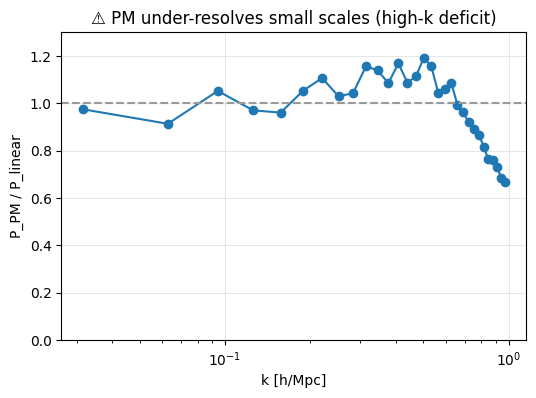

P_pm/P_lin:  lowk 0.97  highk 0.91


In [7]:
lin0 = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
k, pr = power_ratio(df, lin0, box_size=BOX)
plt.figure(figsize=(6,4)); plt.semilogx(k, pr, 'o-')
plt.axhline(1, color='.6', ls='--'); plt.ylim(0,1.3)
plt.xlabel('k [h/Mpc]'); plt.ylabel('P_PM / P_linear')
plt.title('⚠️ PM under-resolves small scales (high-k deficit)'); plt.grid(alpha=.3); plt.show()
print('P_pm/P_lin:  lowk', round(float(np.nanmedian(pr[k<0.06])),2),
      ' highk', round(float(np.nanmedian(pr[k>0.5])),2))